In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [15]:
data = pd.read_csv('air_quality_data.csv')


In [16]:
data.head()

,datetime,location_id,pm25,pm1,pm10,relativehumidity,temperature,um003,name,lat,lon,provider_name
0,2020-04-09 16:00:00+00:00,8876,6.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
1,2020-04-09 17:00:00+00:00,8876,10.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
2,2020-04-09 18:00:00+00:00,8876,8.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
3,2020-04-09 19:00:00+00:00,8876,6.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
4,2020-04-09 20:00:00+00:00,8876,4.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow


In [17]:
data = data.dropna()
data.columns = [col.strip().lower() for col in data.columns]

In [20]:
data.columns

Index(['datetime', 'location_id', 'pm25', 'pm1', 'pm10', 'relativehumidity',
       'temperature', 'um003', 'name', 'lat', 'lon', 'provider_name'],
      dtype='object')

In [21]:
data.isnull().sum()

datetime            0
location_id         0
pm25                0
pm1                 0
pm10                0
relativehumidity    0
temperature         0
um003               0
name                0
lat                 0
lon                 0
provider_name       0
dtype: int64

In [26]:
data.describe()

,location_id,pm25,pm1,pm10,relativehumidity,temperature,um003,lat,lon
count,10203.0,10203.000000,10203.000000,10203.000000,10203.000000,10203.000000,10203.000000,1.020300e+04,1.020300e+04
mean,3243331.0,38.580097,22.744089,35.470496,43.738512,14.242292,4258.337289,4.321065e+01,7.694650e+01
std,0.0,33.515342,18.147216,22.628648,11.171563,9.167631,3799.930730,9.621220e-12,1.310305e-11
min,3243331.0,0.066667,0.000000,0.083333,17.614000,-3.278667,96.062499,4.321065e+01,7.694650e+01
25%,3243331.0,16.059062,10.424687,30.161375,34.695087,6.393813,1858.034363,4.321065e+01,7.694650e+01
50%,3243331.0,28.662757,17.763194,30.161375,44.337042,12.993167,2709.235433,4.321065e+01,7.694650e+01
75%,3243331.0,49.494542,29.271458,30.161375,51.594604,21.971396,5312.419812,4.321065e+01,7.694650e+01
max,3243331.0,297.440998,161.070001,319.395507,89.046834,38.751792,33613.908529,4.321065e+01,7.694650e+01


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10203 entries, 496046 to 506248
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          10203 non-null  object 
 1   location_id       10203 non-null  int64  
 2   pm25              10203 non-null  float64
 3   pm1               10203 non-null  float64
 4   pm10              10203 non-null  float64
 5   relativehumidity  10203 non-null  float64
 6   temperature       10203 non-null  float64
 7   um003             10203 non-null  float64
 8   name              10203 non-null  object 
 9   lat               10203 non-null  float64
 10  lon               10203 non-null  float64
 11  provider_name     10203 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 1.0+ MB


<Axes: >

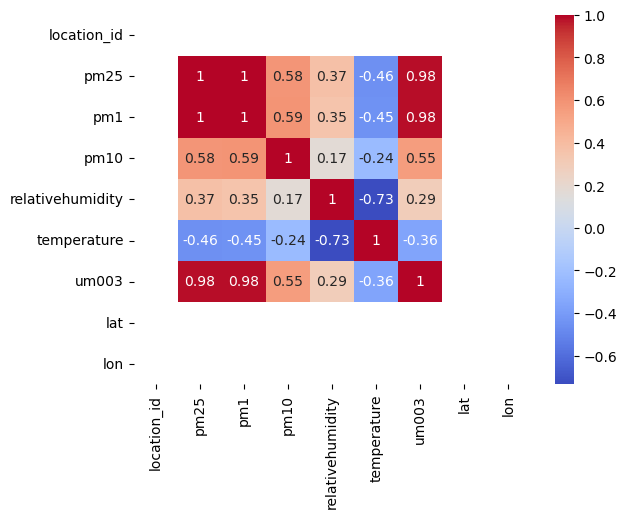

In [25]:
corr = data.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [33]:
X = data[['pm1', 'pm10', 'relativehumidity', 'temperature']]
y = data['pm25']

In [34]:
X = data[['pm1', 'pm25', 'relativehumidity', 'temperature']]
y = data['pm10']

In [35]:
def calculate_aqi(pm25):
    if pm25 <= 50:
        return "Good"
    elif pm25 <= 100:
        return "Moderate"
    else:
        return "Poor"

data['aqi'] = data['pm25'].apply(calculate_aqi)

In [36]:
X = data[['pm1', 'pm10', 'relativehumidity', 'temperature']]
y = data['aqi']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
mapping = {
    'Good': 0,
    'Moderate': 1,
    'Poor': 2
}

y = data['aqi'].map(mapping)

In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y = data['aqi']   # 'Good', 'Moderate', etc.

In [46]:
y = data['pm25']   # numeric

In [47]:
mapping = {'Good': 0, 'Moderate': 1, 'Poor': 2}
y = data['aqi'].map(mapping)

In [48]:
print(X.dtypes)

pm1                 float64
pm10                float64
relativehumidity    float64
temperature         float64
dtype: object


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
X = data[['pm1', 'pm10', 'relativehumidity', 'temperature']]
y = data['pm25']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train (must run without error)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.2937024727314512
MSE: 5.689222709243641
R2: 0.994712826620443


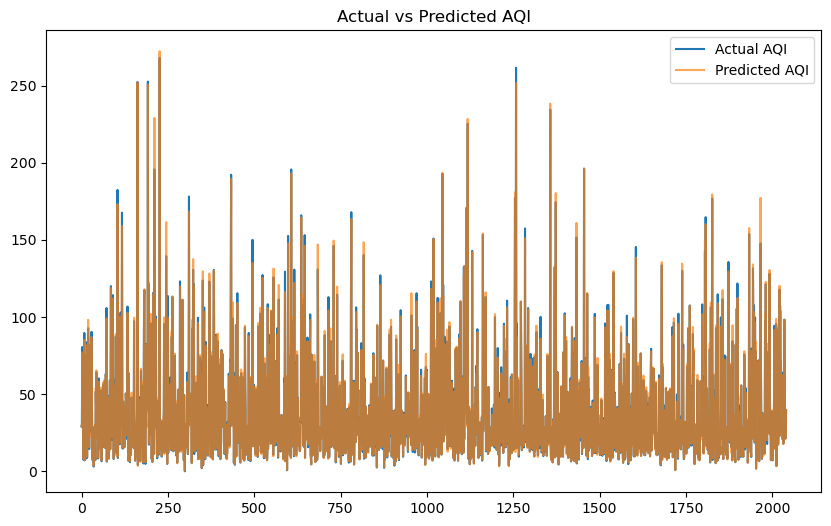

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual AQI')
plt.plot(y_pred, label='Predicted AQI', alpha=0.7)
plt.title('Actual vs Predicted AQI')
plt.legend()
plt.show()